# Earth load Love numbers: TidalPy vs published models

The 1D radial solver computes a body's Love numbers from its interior structure. This benchmark checks
it against two independent Earth models from the literature:

- **Guo et al. (2004)**: a PREM-like three-layer Earth (solid inner core, liquid outer core, solid
  mantle),
- **Farrell (1972)**, using the Alterman et al. (1961) Gutenberg structure: a two-layer Earth (liquid
  core, solid mantle).

We compare the surface **load** Love numbers `h'` and `k'` as a function of harmonic degree, computed by
TidalPy's `RadialSolver_x` from each model's density and seismic-velocity profile, against the values
those papers report.

The reference datasets `Guo+2004.npy` and `Farrell1972.npy` sit next to this notebook. Each is a radial
profile with columns `[radius (km), density (g/cc), Vs (km/s), Vp (km/s)]`, center to surface. The
elastic moduli come from the seismic velocities: `mu = Vs^2 rho`, `K = Vp^2 rho - (4/3) mu`.


In [1]:
%matplotlib inline
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logging.disable(logging.WARNING)   # the solver notes high step counts for the stiff high-degree solves

from TidalPy.RadialSolver_x import build_rs_input_from_data, radial_solver
from TidalPy.rheology import Elastic     # purely elastic response for a Love-number comparison

HERE = Path().resolve()
FORCING = 2.0 * np.pi / 86400.0          # one-day forcing (the value is immaterial for elastic Love numbers)

def load_model(filename, upper_radii, layer_types, is_static):
    "Return a solver for one Earth model: solve(degree, incompressible) -> (h', k', success)."
    data = np.load(HERE / filename)
    radius = data[:, 0] * 1e3
    density = data[:, 1] * 1e3
    shear = (data[:, 2] * 1e3)**2 * density
    bulk = (data[:, 3] * 1e3)**2 * density - (4.0 / 3.0) * shear
    dummy_visc = np.full_like(radius, 1e30)   # unused for an elastic rheology
    n_layers = len(layer_types)

    def solve(degree, incompressible):
        rs_input = build_rs_input_from_data(
            FORCING, radius, density, bulk, shear, dummy_visc, dummy_visc,
            upper_radii, layer_types, is_static, tuple(incompressible for _ in range(n_layers)),
            tuple(Elastic() for _ in range(n_layers)), tuple(Elastic() for _ in range(n_layers)),
            perform_checks=False, warnings=False)
        sol = radial_solver(*rs_input, degree_l=degree, solve_for=("tidal", "loading"),
                            use_kamata=incompressible, nondimensionalize=True,
                            integration_method="RK45", starting_radius=0.1,
                            integration_rtol=1e-8, integration_atol=1e-12)
        h_load = complex(np.atleast_1d(sol.h)[1]).real   # index 1 = loading solution
        k_load = complex(np.atleast_1d(sol.k)[1]).real
        return h_load, k_load, sol.success
    return solve

guo = load_model("Guo+2004.npy", (1.2225e6, 3.4810e6, 6.3710e6),
                 ("solid", "liquid", "solid"), (False, True, False))
farrell = load_model("Farrell1972.npy", (3.473e6, 6.371e6),
                     ("liquid", "solid"), (True, False))
print("models loaded")


models loaded


> Note: the input builder helpers (`build_rs_input_*`) accept the classic `TidalPy.rheology` model objects, which is why this notebook imports them instead of the newer `TidalPy.rheology_x` classes taught in the demos. The builders and their rheology interface will migrate together when the classic backend is retired.


## Guo et al. (2004)

TidalPy's load Love numbers, computed with both compressible and incompressible assumptions, against the reference values. Note that the reference `k'` is reported as `n * k'`, so we divide it by degree to compare with the solver's `k'`. The compressible curve tracks the reference across every degree; making the Earth incompressible visibly changes the response.

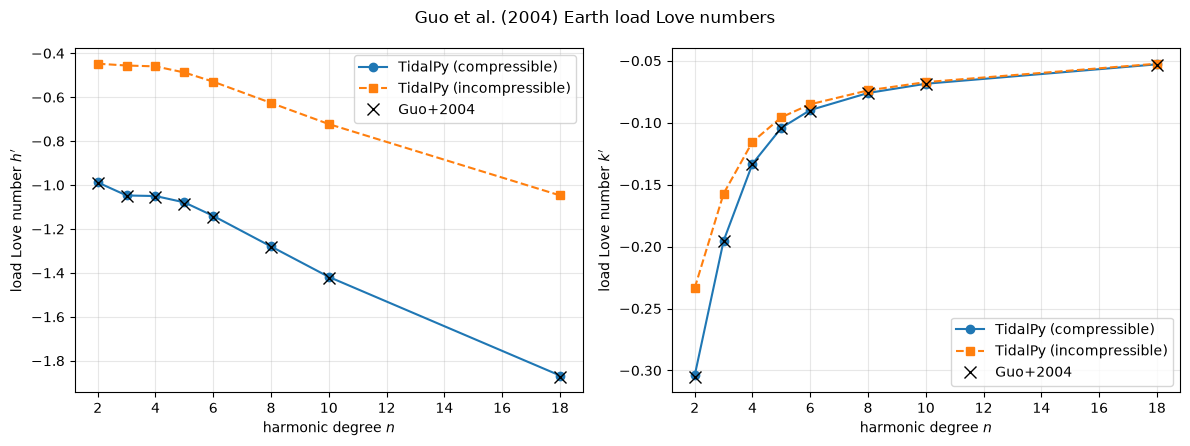

  n  h_TidalPy    h_Guo  k_TidalPy    k_Guo
  2    -0.9880  -0.9909    -0.3040  -0.3051
  3    -1.0476  -1.0501    -0.1953  -0.1959
  4    -1.0501  -1.0528    -0.1332  -0.1335
  5    -1.0790  -1.0857    -0.1041  -0.1046
  6    -1.1406  -1.1433    -0.0898  -0.0902
  8    -1.2798  -1.2833    -0.0760  -0.0764
 10    -1.4182  -1.4226    -0.0686  -0.0689
 18    -1.8672  -1.8733    -0.0529  -0.0534


In [2]:
degrees = np.array([2, 3, 4, 5, 6, 8, 10, 18])
guo_h_ref = -np.array([0.9909, 1.0501, 1.0528, 1.0857, 1.1433, 1.2833, 1.4226, 1.8733])
guo_kn_ref = -np.array([0.6103, 0.5876, 0.5341, 0.5228, 0.5411, 0.61107, 0.6893, 0.961])
guo_k_ref = guo_kn_ref / degrees      # the paper plots n * k'

h_comp = np.array([guo(d, False)[0] for d in degrees])
k_comp = np.array([guo(d, False)[1] for d in degrees])
h_inco = np.array([guo(d, True)[0] for d in degrees])
k_inco = np.array([guo(d, True)[1] for d in degrees])

fig, (axh, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(degrees, h_comp, "o-", label="TidalPy (compressible)")
axh.plot(degrees, h_inco, "s--", label="TidalPy (incompressible)")
axh.plot(degrees, guo_h_ref, "kx", ms=9, label="Guo+2004")
axh.set_ylabel("load Love number $h'$")
axk.plot(degrees, k_comp, "o-", label="TidalPy (compressible)")
axk.plot(degrees, k_inco, "s--", label="TidalPy (incompressible)")
axk.plot(degrees, guo_k_ref, "kx", ms=9, label="Guo+2004")
axk.set_ylabel("load Love number $k'$")
for ax in (axh, axk):
    ax.set_xlabel("harmonic degree $n$"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Guo et al. (2004) Earth load Love numbers")
fig.tight_layout(); plt.show()

print(f"{'n':>3} {'h_TidalPy':>10} {'h_Guo':>8} {'k_TidalPy':>10} {'k_Guo':>8}")
for i, d in enumerate(degrees):
    print(f"{d:3d} {h_comp[i]:10.4f} {guo_h_ref[i]:8.4f} {k_comp[i]:10.4f} {guo_k_ref[i]:8.4f}")


## Farrell (1972)

The two-layer model corroborates the comparison at degrees 3 and above (its degree-2 solve does not converge for this particular liquid-core structure, so it is omitted).

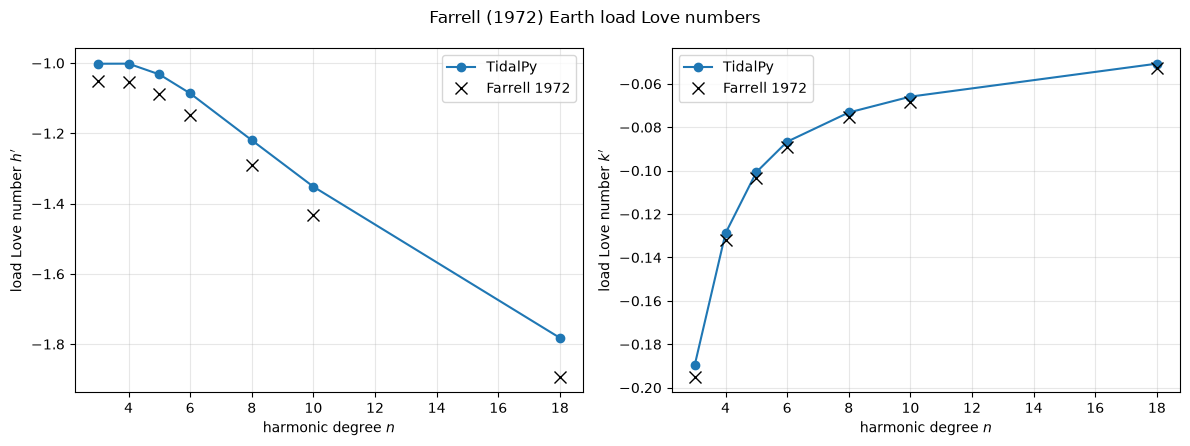

max |h' - reference| : 0.1109
max |k' - reference| : 0.0054


In [3]:
far_degrees = np.array([3, 4, 5, 6, 8, 10, 18])
far_h_ref = -np.array([1.052, 1.053, 1.088, 1.147, 1.291, 1.433, 1.893])
far_kn_ref = -np.array([0.585, 0.528, 0.516, 0.535, 0.604, 0.682, 0.952])
far_k_ref = far_kn_ref / far_degrees

fh = np.array([farrell(d, False)[0] for d in far_degrees])
fk = np.array([farrell(d, False)[1] for d in far_degrees])

fig, (axh, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(far_degrees, fh, "o-", label="TidalPy")
axh.plot(far_degrees, far_h_ref, "kx", ms=9, label="Farrell 1972")
axh.set_ylabel("load Love number $h'$")
axk.plot(far_degrees, fk, "o-", label="TidalPy")
axk.plot(far_degrees, far_k_ref, "kx", ms=9, label="Farrell 1972")
axk.set_ylabel("load Love number $k'$")
for ax in (axh, axk):
    ax.set_xlabel("harmonic degree $n$"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Farrell (1972) Earth load Love numbers")
fig.tight_layout(); plt.show()

print(f"max |h' - reference| : {np.max(np.abs(fh - far_h_ref)):.4f}")
print(f"max |k' - reference| : {np.max(np.abs(fk - far_k_ref)):.4f}")


## Recap

- TidalPy's `RadialSolver_x` reproduces the published Earth load Love numbers `h'` and `k'` from the
  Guo et al. (2004) and Farrell (1972) interior models, across harmonic degrees from 2 to 18.
- The compressible solution tracks the references closely; the incompressible assumption gives a
  visibly different, stiffer response, as expected.
- The comparison is driven straight from each model's radial density and seismic-velocity profile via
  `build_rs_input_from_data`, with a purely elastic rheology.
